In [1]:
!pip install -q newspaper3k nltk scikit-learn vaderSentiment transformers torch lxml_html_clean

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from newspaper import Article
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from transformers import pipeline
import matplotlib.pyplot as plt

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [2]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch

# Load BART via Auto classes (avoids version conflicts)
bart_tokenizer = AutoTokenizer.from_pretrained('facebook/bart-large-cnn')
bart_model     = AutoModelForSeq2SeqLM.from_pretrained('facebook/bart-large-cnn')

def bart_summarize(text, max_length=200, min_length=80):
    inputs = bart_tokenizer(
        text,
        return_tensors='pt',
        max_length=1024,
        truncation=True
    )
    ids = bart_model.generate(
        inputs['input_ids'],
        max_length=max_length,
        min_length=min_length,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )
    return bart_tokenizer.decode(ids[0], skip_special_tokens=True)

emo_pipe = pipeline('text-classification',
                    model='j-hartmann/emotion-english-distilroberta-base',
                    top_k=None)

print("Models loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Models loaded.


In [5]:
import requests

# Fetching from an open mirror site that has the full transcript
url = 'https://singjupost.com/transcript-of-openais-sam-altman-on-the-future-of-ai-safety-and-power-live-at-ted2025/'

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
response = requests.get(url, headers=headers)

from newspaper import Article
article = Article(url)
article.set_html(response.text)
article.parse()
article.nlp()
text = article.text

print(f"Status : {response.status_code}")
print(f"Title  : {article.title}")
print(f"Words  : {len(text.split())}")
print(f"\nPreview:\n{text[:500]}")

Status : 200
Title  : Transcript of OpenAI’s Sam Altman on the Future of AI, Safety and Power — Live at TED2025
Words  : 8379

Preview:
SAM ALTMAN: So right now, if you use our image generation thing and say, “I want something in the style of a living artist,” it won’t do that. But if you say, “I want it in the style of this particular kind of vibe or this studio or this art movement or whatever,” it will. Obviously, if you’re like, “Output a song that is like a copy of the song,” it won’t do that. The question of where that line should be and how people say “this is too much” – we sorted that out before with copyright law and k


## 1. Use an LLM to summarize the article.  

In [7]:
trunc   = ' '.join(text.split()[:800])
summary = bart_summarize(trunc, max_length=200, min_length=80)
print(summary)

ChatGPT is a computer program that generates images in the style of living artists. ChatGPT has been developed by G4.0, which is part of the G4 network. G4 is developing a new generation of computers that will be able to do a lot more. The company is also working on a new version of its software, called ChatG PT 2.0. Click through the video to see more.


## 2. Identify the key topics, and the sentiment. Is the sentiment measured by the LLM different from one using a classification model such as Naïve Bayes or Support Vector Machine?  

In [9]:
topic_input = "The key topics discussed in this article are: " + ' '.join(text.split()[:800])
topics      = bart_summarize(topic_input, max_length=120, min_length=40)
print(topics)

# --- VADER ---
sia          = SentimentIntensityAnalyzer()
sentences    = nltk.sent_tokenize(text)
vader_scores = [sia.polarity_scores(s) for s in sentences]
avg_compound = sum(s['compound'] for s in vader_scores) / len(vader_scores)
vader_label  = 'Positive' if avg_compound >= 0.05 else ('Negative' if avg_compound <= -0.05 else 'Neutral')
print(f"\n=== VADER Sentiment ===")
print(f"Avg Compound: {avg_compound:.4f}  =>  {vader_label}")

# --- Naïve Bayes + SVM (pseudo-labeled via VADER) ---
labeled = []
for sent, score in zip(sentences, vader_scores):
    if score['compound'] >= 0.05:    label = 'Positive'
    elif score['compound'] <= -0.05: label = 'Negative'
    else:                             label = 'Neutral'
    labeled.append((sent, label))

texts_train, labels_train = zip(*labeled)
vec = TfidfVectorizer(stop_words='english', max_features=500)
X   = vec.fit_transform(texts_train)
le  = LabelEncoder()
y   = le.fit_transform(labels_train)

nb_preds  = le.inverse_transform(MultinomialNB().fit(X, y).predict(X))
svm_preds = le.inverse_transform(LinearSVC(max_iter=1000).fit(X, y).predict(X))
nb_label  = max(set(nb_preds),  key=list(nb_preds).count)
svm_label = max(set(svm_preds), key=list(svm_preds).count)

# --- BART Sentiment ---
sent_input     = "The overall sentiment of this article is: " + ' '.join(text.split()[:600])
bart_sentiment = bart_summarize(sent_input, max_length=20, min_length=5)

print(f"\n=== SENTIMENT COMPARISON ===")
print(f"  BART (LLM)    : {bart_sentiment}")
print(f"  VADER         : {vader_label}")
print(f"  Naïve Bayes   : {nb_label}")
print(f"  SVM           : {svm_label}")

ChatGPT is a new generation of image generation technology. ChatGPT can generate content in the style of a living artist or a particular vibe. The technology is being developed by a group called G40.

=== VADER Sentiment ===
Avg Compound: 0.2263  =>  Positive

=== SENTIMENT COMPARISON ===
  BART (LLM)    : ChatGPT can generate art in the style of people who have consented to it
  VADER         : Positive
  Naïve Bayes   : Positive
  SVM           : Positive


## 3. What is the general emotion of the article?

In [11]:
sample      = ' '.join(text.split()[:300])
emo_results = sorted(
    emo_pipe(sample, truncation=True, max_length=512)[0],
    key=lambda x: x['score'], reverse=True
)
for e in emo_results:
    print(f"  {e['label']:15s}: {e['score']:.4f}")
print(f"\n  Dominant Emotion: {emo_results[0]['label'].upper()}")

  neutral        : 0.9109
  disgust        : 0.0422
  anger          : 0.0205
  surprise       : 0.0164
  sadness        : 0.0045
  fear           : 0.0036
  joy            : 0.0018

  Dominant Emotion: NEUTRAL


## 4. What is the main theme of the article?

In [12]:
theme_input = "The main theme and central argument of this article is: " + ' '.join(text.split()[:800])
theme       = bart_summarize(theme_input, max_length=80, min_length=30)
print(theme)

ChatGPT is a new type of image generation system. It can generate content in the style of a living artist or a particular art movement. ChatGPT can also generate content based on a user’s request.


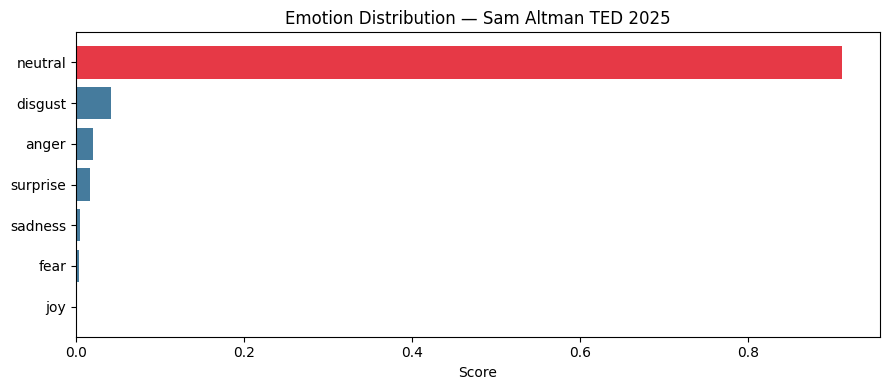

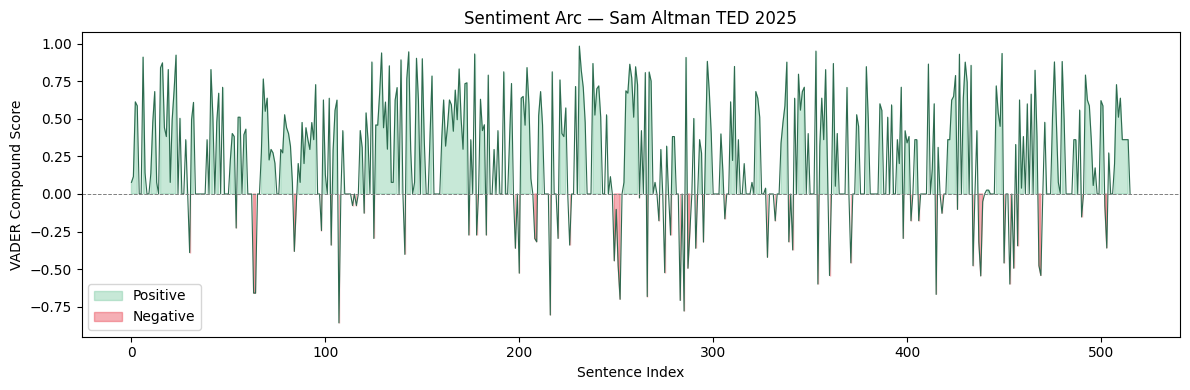

In [14]:
# Chart 1: Emotion Bar Chart
emotions   = [e['label'] for e in emo_results]
emo_scores = [e['score'] for e in emo_results]
colors     = ['#e63946' if i == 0 else '#457b9d' for i in range(len(emotions))]

plt.figure(figsize=(9, 4))
plt.barh(emotions[::-1], emo_scores[::-1], color=colors[::-1])
plt.xlabel('Score')
plt.title('Emotion Distribution — Sam Altman TED 2025')
plt.tight_layout()
plt.savefig('hw7_emotions.png', dpi=150)
plt.show()

# Chart 2: VADER Sentiment Arc
compound_series = [s['compound'] for s in vader_scores]
plt.figure(figsize=(12, 4))
plt.plot(compound_series, color='#2d6a4f', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
plt.fill_between(range(len(compound_series)), compound_series, 0,
                 where=[c > 0 for c in compound_series], color='#74c69d', alpha=0.4, label='Positive')
plt.fill_between(range(len(compound_series)), compound_series, 0,
                 where=[c < 0 for c in compound_series], color='#e63946', alpha=0.4, label='Negative')
plt.xlabel('Sentence Index')
plt.ylabel('VADER Compound Score')
plt.title('Sentiment Arc — Sam Altman TED 2025')
plt.legend()
plt.tight_layout()
plt.savefig('hw7_sentiment_arc.png', dpi=150)
plt.show()